# HUMA EJAZ
# 481480

In [2]:
#installing the libraries

!pip install torch torchvision torchaudio --quiet
!pip install transformers timm peft accelerate scikit-learn matplotlib opencv-python pandas --quiet


In [3]:
#imports and basic settings

import os
import math
import random
from glob import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPProcessor, CLIPModel

import numpy as np
import pandas as pd
import cv2
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Emotion classes

EMOTIONS = [
    "neutral",
    "happy",
    "surprise",
    "sad",
    "anger",
    "disgust",
    "fear",
    "contempt"
]
num_classes = len(EMOTIONS)
emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}
idx_to_emotion = {i: e for e, i in emotion_to_idx.items()}


In [5]:
#Mounting Drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
DATA_DIR = "/content/drive/MyDrive/rafdb_simplified"  # change if your folder is different
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")


In [7]:
#Simple dataset class

class RAFFolderDataset(Dataset):
    def __init__(self, root_dir, processor, transform_size=224):
        self.root_dir = root_dir
        self.processor = processor

        self.samples = []
        for emotion in EMOTIONS:
            class_dir = os.path.join(root_dir, emotion)
            if not os.path.isdir(class_dir):
                continue  # class may be missing in that split
            image_paths = glob(os.path.join(class_dir, "*"))
            for p in image_paths:
                self.samples.append((p, emotion_to_idx[emotion]))

        print(f"Loaded {len(self.samples)} images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # read image with cv2 (BGR → RGB)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # we won’t transform here; CLIPProcessor will do resize + normalization
        return img, label, img_path


In [8]:
TRAIN_DIR = "/content/drive/MyDrive/RAF-DB/DATASET/train"
VAL_DIR   = "/content/drive/MyDrive/RAF-DB/DATASET/test"

In [9]:
#Emotion Mapping

# numeric-ID -> emotion name (matches RAF-DB convention)
ID2EMO = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sad",
    "6": "anger",
    "7": "neutral"
}

EMOTIONS = [ID2EMO[str(i)] for i in range(1, 8)]
print(EMOTIONS)

emotion_to_idx = {emo: i for i, emo in enumerate(EMOTIONS)}
idx_to_emotion = {i: emo for emo, i in emotion_to_idx.items()}


['surprise', 'fear', 'disgust', 'happy', 'sad', 'anger', 'neutral']


In [10]:
#Dataset class

import os, glob
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

class RAFFolderDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.root_dir = root_dir
        self.processor = processor
        self.samples = []

        # loop over class folders: '1', '2', ..., '7'
        for class_id in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_id)
            if not os.path.isdir(class_path):
                continue
            emo_name = ID2EMO[class_id]          # e.g. '4' -> 'happy'
            label_idx = emotion_to_idx[emo_name] # 0..6

            for img_path in glob.glob(os.path.join(class_path, "*")):
                self.samples.append((img_path, label_idx))

        print(f"Loaded {len(self.samples)} images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR -> RGB
        return img, label, img_path


In [11]:
#Loading CLIP model and processor

from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)



Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [12]:
#Dataset and Loaders

train_dataset = RAFFolderDataset(TRAIN_DIR, clip_processor)
val_dataset   = RAFFolderDataset(VAL_DIR, clip_processor)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

len(train_dataset), len(val_dataset)

Loaded 12271 images from /content/drive/MyDrive/RAF-DB/DATASET/train
Loaded 3068 images from /content/drive/MyDrive/RAF-DB/DATASET/test


(12271, 3068)

In [13]:
#Zero-shot CLIP(B0) prompts

import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

TEMPLATES = [
    "a face showing {} expression",
    "a portrait of a person looking {}",
    "a close-up photo, {} emotion"
]

def build_text_embeddings(model, processor, device):
    texts = []
    for emo in EMOTIONS:
        for tmpl in TEMPLATES:
            texts.append(tmpl.format(emo))
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        text_feats = model.get_text_features(
            input_ids=inputs["input_ids"].to(device),
            attention_mask=inputs["attention_mask"].to(device)
        )
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

    k = len(TEMPLATES)
    per_class = []
    for ci in range(len(EMOTIONS)):
        per_class.append(text_feats[ci*k:(ci+1)*k].mean(dim=0))
    return torch.stack(per_class, dim=0)   # (num_classes, dim)

text_embeds = build_text_embeddings(clip_model, clip_processor, device)
text_embeds.shape


torch.Size([7, 512])

In [15]:
#Zero-shot prediction

def zeroshot_predict_batch(images):
    # images: list of np arrays
    inputs = clip_processor(images=images, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_feats = clip_model.get_image_features(**inputs)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    sims = img_feats @ text_embeds.T   # (batch, num_classes)
    preds = sims.argmax(dim=-1).cpu().numpy()
    return preds

all_labels = []
all_preds  = []

for imgs, labels, _ in val_loader:
    imgs_np = [img.numpy() for img in imgs]
    preds = zeroshot_predict_batch(imgs_np)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Zero-shot CLIP on VAL set")
print("Accuracy:", acc)
print("Macro-F1:", macro_f1)
print()
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))


Zero-shot CLIP on VAL set
Accuracy: 0.39146023468057367
Macro-F1: 0.35323597334115714

              precision    recall  f1-score   support

    surprise       0.30      0.52      0.38       329
        fear       0.21      0.22      0.21        74
     disgust       0.12      0.66      0.21       160
       happy       0.97      0.42      0.59      1185
         sad       0.60      0.37      0.46       478
       anger       0.27      0.73      0.40       162
     neutral       0.36      0.17      0.23       680

    accuracy                           0.39      3068
   macro avg       0.41      0.44      0.35      3068
weighted avg       0.61      0.39      0.43      3068



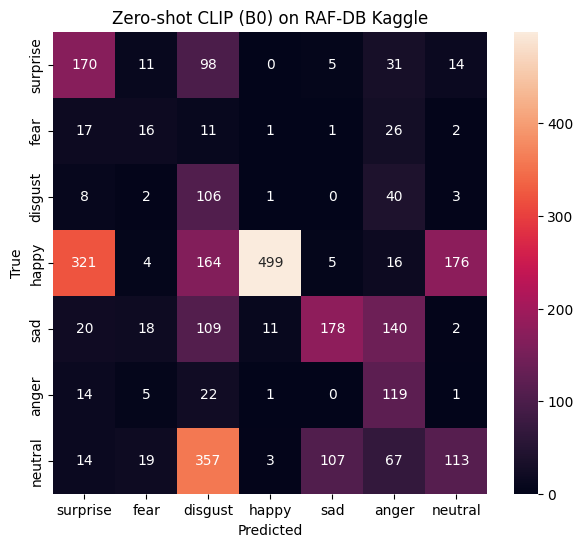

In [16]:
#Confusion Matrix

import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Zero-shot CLIP (B0) on RAF-DB Kaggle")
plt.show()


In [17]:
#Freeze the CLIP Model and switching to evaluation

for p in clip_model.parameters():
    p.requires_grad = False

clip_model.eval()
print("CLIP frozen and in eval mode.")


CLIP frozen and in eval mode.


In [20]:
#Extract CLIP image features

import torch
import numpy as np
from tqdm import tqdm

def extract_clip_features(dataloader):
    feats = []
    labels_all = []

    for imgs, labels, _ in tqdm(dataloader):
        imgs_np = [img.numpy() for img in imgs]

        inputs = clip_processor(
            images=imgs_np,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            img_feats = clip_model.get_image_features(**inputs)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

        feats.append(img_feats.cpu())
        labels_all.append(labels)

    feats = torch.cat(feats, dim=0)          # (N, dim)
    labels_all = torch.cat(labels_all, dim=0)  # (N,)
    return feats, labels_all


In [21]:
#Extract features for train and val sets

train_feats, train_labels = extract_clip_features(train_loader)
val_feats,   val_labels   = extract_clip_features(val_loader)

print("Train features:", train_feats.shape)
print("Val features:  ", val_feats.shape)


100%|██████████| 96/96 [00:19<00:00,  4.92it/s]

Train features: torch.Size([12271, 512])
Val features:   torch.Size([3068, 512])


In [22]:
# Linear Classifier

import torch.nn as nn

num_classes = len(EMOTIONS)
feat_dim = train_feats.shape[1]   # 512

class LinearHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

linear_head = LinearHead(feat_dim, num_classes).to(device)
print(linear_head)


LinearHead(
  (fc): Linear(in_features=512, out_features=7, bias=True)
)


In [23]:
#Training loop for Linear loop

from torch.utils.data import TensorDataset, DataLoader

# Wrap features into TensorDatasets for easy batching
train_ds_lin = TensorDataset(train_feats, train_labels)
val_ds_lin   = TensorDataset(val_feats,   val_labels)

train_loader_lin = DataLoader(train_ds_lin, batch_size=64, shuffle=True)
val_loader_lin   = DataLoader(val_ds_lin,   batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_head.parameters(), lr=1e-3)

def eval_linear(head, loader):
    head.eval()
    correct, total = 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = head(x)
            preds = logits.argmax(dim=-1)

            correct += (preds == y).sum().item()
            total   += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = correct / total
    return acc, np.array(all_labels), np.array(all_preds)

# Train for a few epochs
EPOCHS = 10

for epoch in range(1, EPOCHS+1):
    linear_head.train()
    running_loss = 0.0

    for x, y in train_loader_lin:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = linear_head(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_ds_lin)
    val_acc, _, _ = eval_linear(linear_head, val_loader_lin)
    print(f"Epoch {epoch:02d} | train_loss = {train_loss:.4f} | val_acc = {val_acc*100:.2f}%")


Epoch 01 | train_loss = 1.6422 | val_acc = 43.22%
Epoch 02 | train_loss = 1.3844 | val_acc = 53.85%
Epoch 03 | train_loss = 1.2504 | val_acc = 58.70%
Epoch 04 | train_loss = 1.1507 | val_acc = 63.20%
Epoch 05 | train_loss = 1.0727 | val_acc = 65.94%
Epoch 06 | train_loss = 1.0102 | val_acc = 69.52%
Epoch 07 | train_loss = 0.9586 | val_acc = 71.48%
Epoch 08 | train_loss = 0.9156 | val_acc = 73.37%
Epoch 09 | train_loss = 0.8791 | val_acc = 74.71%
Epoch 10 | train_loss = 0.8477 | val_acc = 75.33%


In [24]:
#Evaluate with accuracy and macro-F1

from sklearn.metrics import accuracy_score, f1_score, classification_report

val_acc, val_labels_np, val_preds_np = eval_linear(linear_head, val_loader_lin)

macro_f1 = f1_score(val_labels_np, val_preds_np, average="macro")

print("Linear Probe on CLIP features (VAL set)")
print("Accuracy:", val_acc)
print("Macro-F1:", macro_f1)
print()
print(classification_report(val_labels_np, val_preds_np, target_names=EMOTIONS))


Linear Probe on CLIP features (VAL set)
Accuracy: 0.7532594524119948
Macro-F1: 0.5501074873006953

              precision    recall  f1-score   support

    surprise       0.82      0.57      0.67       329
        fear       0.00      0.00      0.00        74
     disgust       0.60      0.17      0.26       160
       happy       0.79      0.96      0.87      1185
         sad       0.74      0.75      0.75       478
       anger       0.64      0.52      0.57       162
     neutral       0.70      0.76      0.73       680

    accuracy                           0.75      3068
   macro avg       0.61      0.53      0.55      3068
weighted avg       0.73      0.75      0.73      3068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
#Evaluation cell

from sklearn.metrics import accuracy_score, f1_score, classification_report

val_acc, val_labels_np, val_preds_np = eval_linear(linear_head, val_loader_lin)

macro_f1 = f1_score(val_labels_np, val_preds_np, average="macro")

print("Linear Probe on CLIP features (VAL set)")
print("Accuracy:", val_acc)
print("Macro-F1:", macro_f1)
print()
print(classification_report(val_labels_np, val_preds_np, target_names=EMOTIONS))


Linear Probe on CLIP features (VAL set)
Accuracy: 0.7532594524119948
Macro-F1: 0.5501074873006953

              precision    recall  f1-score   support

    surprise       0.82      0.57      0.67       329
        fear       0.00      0.00      0.00        74
     disgust       0.60      0.17      0.26       160
       happy       0.79      0.96      0.87      1185
         sad       0.74      0.75      0.75       478
       anger       0.64      0.52      0.57       162
     neutral       0.70      0.76      0.73       680

    accuracy                           0.75      3068
   macro avg       0.61      0.53      0.55      3068
weighted avg       0.73      0.75      0.73      3068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
#Install peft

!pip install peft --quiet

In [27]:
from peft import LoraConfig, get_peft_model, TaskType

# using the clip_model, device

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],  # CLIP attention modules
)

clip_lora = get_peft_model(clip_model, lora_config)
clip_lora.to(device)
clip_lora.print_trainable_parameters()


trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456


In [28]:
#Linear head for LoRA training

import torch.nn as nn

feat_dim = train_feats.shape[1]
num_classes = len(EMOTIONS)

class LinearHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

lora_head = LinearHead(feat_dim, num_classes).to(device)


In [29]:
#Training loop: LoRA + head on RAF-DB

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

# already have: train_dataset, val_dataset
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    list(clip_lora.parameters()) + list(lora_head.parameters()),
    lr=1e-4
)

In [30]:
#Training function

def train_lora_epoch(model, head, dataloader, optimizer, device):
    model.train()
    head.train()
    running_loss = 0.0

    for imgs, labels, _ in tqdm(dataloader):
        # convert batch to list of numpy arrays for processor
        imgs_np = [img.numpy() for img in imgs]

        inputs = clip_processor(
            images=imgs_np,
            return_tensors="pt",
            padding=True
        ).to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        # get image features from CLIP+LoRA
        img_feats = model.get_image_features(**inputs)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

        logits = head(img_feats)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(dataloader.dataset)


In [31]:
#Evaluation fuction

from sklearn.metrics import accuracy_score, f1_score

def eval_lora(model, head, dataloader, device):
    model.eval()
    head.eval()

    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for imgs, labels, _ in dataloader:
            imgs_np = [img.numpy() for img in imgs]
            inputs = clip_processor(
                images=imgs_np,
                return_tensors="pt",
                padding=True
            ).to(device)

            labels = labels.to(device)

            img_feats = model.get_image_features(**inputs)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

            logits = head(img_feats)
            preds = logits.argmax(dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, macro_f1, all_labels, all_preds


In [32]:
#LoRA training(few epochs)

EPOCHS = 3

for epoch in range(1, EPOCHS+1):
    train_loss = train_lora_epoch(clip_lora, lora_head, train_loader, optimizer, device)
    val_acc, val_f1, _, _ = eval_lora(clip_lora, lora_head, val_loader, device)

    print(f"Epoch {epoch:02d} | train_loss = {train_loss:.4f} | "
          f"val_acc = {val_acc*100:.2f}% | val_macroF1 = {val_f1*100:.2f}%")


100%|██████████| 384/384 [02:33<00:00,  2.50it/s]


Epoch 01 | train_loss = 1.5357 | val_acc = 75.36% | val_macroF1 = 48.92%


100%|██████████| 384/384 [02:12<00:00,  2.89it/s]


Epoch 02 | train_loss = 1.0231 | val_acc = 81.68% | val_macroF1 = 56.06%


100%|██████████| 384/384 [02:10<00:00,  2.93it/s]


Epoch 03 | train_loss = 0.7586 | val_acc = 82.76% | val_macroF1 = 58.74%


In [33]:
#Final evaluation

val_acc, val_f1, val_labels_lora, val_preds_lora = eval_lora(clip_lora, lora_head, val_loader, device)

print("LoRA Fine-Tuned CLIP on RAF-DB (VAL)")
print("Accuracy:", val_acc)
print("Macro-F1:", val_f1)
print()
from sklearn.metrics import classification_report
print(classification_report(val_labels_lora, val_preds_lora, target_names=EMOTIONS))


LoRA Fine-Tuned CLIP on RAF-DB (VAL)
Accuracy: 0.8275749674054759
Macro-F1: 0.5874478696517806

              precision    recall  f1-score   support

    surprise       0.71      0.87      0.78       329
        fear       0.00      0.00      0.00        74
     disgust       0.71      0.06      0.11       160
       happy       0.96      0.93      0.94      1185
         sad       0.77      0.86      0.81       478
       anger       0.62      0.60      0.61       162
     neutral       0.79      0.92      0.85       680

    accuracy                           0.83      3068
   macro avg       0.65      0.61      0.59      3068
weighted avg       0.81      0.83      0.80      3068



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


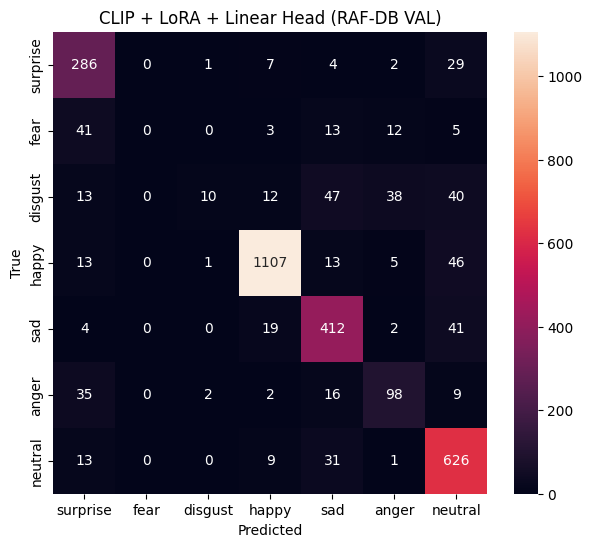

In [34]:
#Confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels_lora, val_preds_lora)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CLIP + LoRA + Linear Head (RAF-DB VAL)")
plt.show()


In [35]:
#Saving the RAF-DB Fine-Tuned Checkpoints

save_path = "/content/drive/MyDrive/EmotionEngine/checkpoints/clip_rafdb_lora.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(clip_lora.state_dict(), save_path)
print("Saved to:", save_path)


Saved to: /content/drive/MyDrive/EmotionEngine/checkpoints/clip_rafdb_lora.pt


In [36]:
# SFEW 2.0 paths
SFEW_ROOT      = "/content/drive/MyDrive/SFEW 2.0"
SFEW_TRAIN_DIR = SFEW_ROOT + "/Train"
SFEW_VAL_DIR   = SFEW_ROOT + "/Val"
SFEW_TEST_DIR  = SFEW_ROOT + "/Test/Test_Aligned_Faces"

print(SFEW_TRAIN_DIR)
print(SFEW_VAL_DIR)
print(SFEW_TEST_DIR)


/content/drive/MyDrive/SFEW 2.0/Train
/content/drive/MyDrive/SFEW 2.0/Val
/content/drive/MyDrive/SFEW 2.0/Test/Test_Aligned_Faces


In [37]:
#Dataset class for SFEW (train/val)

import os
from PIL import Image
from torch.utils.data import Dataset

# same order as for RAF-DB
EMOTIONS = ["surprise", "fear", "disgust", "happy", "sad", "anger", "neutral"]
EMO2ID = {e: i for i, e in enumerate(EMOTIONS)}

class SFEWFolderDataset(Dataset):
    """
    Folder structure:
    SFEW 2.0/
        Train/
            Angry, Happy, ...
        Val/
            Angry, Happy, ...
    Folder names can be any case; we map by lowercasing.
    """
    def __init__(self, root_dir, processor):
        self.processor = processor
        self.samples = []   # (img_path, label_id)

        for class_name in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            emo_name = class_name.lower()
            if emo_name == "angry":
                emo_name = "anger"         # align naming
            if emo_name not in EMO2ID:
                print("Skipping unknown class folder:", class_name)
                continue

            label_id = EMO2ID[emo_name]

            for fname in os.listdir(class_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(
                        (os.path.join(class_path, fname), label_id)
                    )

        print(f"Loaded {len(self.samples)} images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=img, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)  # (3, 224, 224)
        return pixel_values, label


In [38]:
#SFEW train/val loaders

from torch.utils.data import DataLoader

sfew_train_dataset = SFEWFolderDataset(SFEW_TRAIN_DIR, clip_processor)
sfew_val_dataset   = SFEWFolderDataset(SFEW_VAL_DIR, clip_processor)

sfew_train_loader = DataLoader(sfew_train_dataset, batch_size=32, shuffle=True,  num_workers=2)
sfew_val_loader   = DataLoader(sfew_val_dataset,   batch_size=32, shuffle=False, num_workers=2)

len(sfew_train_dataset), len(sfew_val_dataset)


Loaded 893 images from /content/drive/MyDrive/SFEW 2.0/Train
Loaded 431 images from /content/drive/MyDrive/SFEW 2.0/Val


(893, 431)

LoRA Fine-Tuned CLIP on SFEW (VAL)
Accuracy: 0.4222737819025522
Macro-F1: 0.31595894275991177

              precision    recall  f1-score   support

    surprise       0.25      0.41      0.31        56
        fear       0.00      0.00      0.00        46
     disgust       0.14      0.04      0.07        23
       happy       0.53      0.82      0.64        72
         sad       0.50      0.33      0.40        73
       anger       0.81      0.17      0.28        77
     neutral       0.40      0.74      0.52        84

    accuracy                           0.42       431
   macro avg       0.38      0.36      0.32       431
weighted avg       0.44      0.42      0.37       431



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


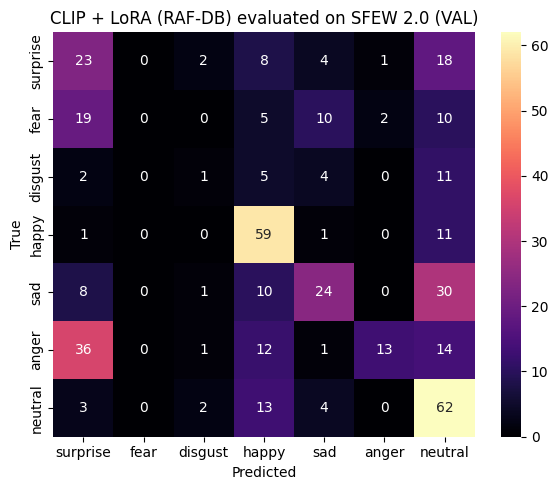

In [39]:
#Evaluate the RAF-LoRA model on SFEW VAL

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# The model to evaluate is clip_lora, and the head is lora_head
clip_lora.eval()
lora_head.eval()

all_labels = []
all_preds  = []

with torch.no_grad():
    for pixel_values, labels in sfew_val_loader:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        # Get image features from the LoRA-tuned CLIP model
        # The SFEW dataset already provides pixel_values as processed tensors
        img_feats = clip_lora.get_image_features(pixel_values=pixel_values)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True) # Normalize features

        # Pass features through the linear head
        logits = lora_head(img_feats)
        preds = torch.argmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("LoRA Fine-Tuned CLIP on SFEW (VAL)")
print("Accuracy:", acc)
print("Macro-F1:", macro_f1)
print()
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CLIP + LoRA (RAF-DB) evaluated on SFEW 2.0 (VAL)")
plt.tight_layout()
plt.show()

# (Gives errors in this cell and onwards, retry tomorrow once reexecuting all the above cells to avoid errors in the further cells)

In [40]:
#FER+ Dataset Class
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

class FERPlusDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.processor = processor
        self.samples = []

        # Check for intermediate directories
        actual_root_dir = root_dir
        possible_intermediate_folders = ["validation", "val", "test", "fer2013plus_val_set_images", "fer2013plus_test_set_images", "fer2013plus"]

        # Heuristic to find the actual root containing emotion folders
        for folder_name in possible_intermediate_folders:
            intermediate_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(intermediate_path) and len(os.listdir(intermediate_path)) > 0:
                actual_root_dir = intermediate_path
                print(f"Detected intermediate directory '{folder_name}'. Adjusting root_dir to: {actual_root_dir}")
                break

        # If no specific intermediate folder was found but there's a single sub-directory, try entering it
        if actual_root_dir == root_dir and len(os.listdir(root_dir)) == 1:
            single_sub_dir_name = os.listdir(root_dir)[0]
            single_sub_dir_path = os.path.join(root_dir, single_sub_dir_name)
            if os.path.isdir(single_sub_dir_path):
                actual_root_dir = single_sub_dir_path
                print(f"Detected single sub-directory '{single_sub_dir_name}'. Adjusting root_dir to: {actual_root_dir}")


        for emotion_name in os.listdir(actual_root_dir):
            emotion_path = os.path.join(actual_root_dir, emotion_name)
            if os.path.isdir(emotion_path):
                # Ensure EMOTIONS list is defined and accessible. It's defined globally in a previous cell.
                # Convert to lowercase for consistent matching, assuming emotion_name from folder is capitalized.
                mapped_emotion_name = emotion_name.lower()
                if mapped_emotion_name == "angry": # SFEW used this, sometimes FER+ also has 'angry'
                    mapped_emotion_name = "anger"
                # Add more mappings if FER+ uses different names, e.g., 'happy' might be 'happiness'
                # Based on the EMOTIONS list from RAF-DB and SFEW: ["surprise", "fear", "disgust", "happy", "sad", "anger", "neutral"]

                try:
                    label_id = EMOTIONS.index(mapped_emotion_name)
                except ValueError:
                    print(f"Warning: Emotion '{mapped_emotion_name}' from folder '{emotion_name}' not found in EMOTIONS list. Skipping.")
                    continue

                for img_file in os.listdir(emotion_path):
                    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.samples.append((os.path.join(emotion_path, img_file), label_id))
        print(f"Loaded {len(self.samples)} images from {actual_root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0), torch.tensor(label)


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
# Load FER+ (FER2013+) Train & Test

from torch.utils.data import DataLoader

# Paths
FERPLUS_ROOT = "/content/drive/MyDrive/FER+/fer2013plus"

FERPLUS_TRAIN = FERPLUS_ROOT + "/train"
FERPLUS_TEST  = FERPLUS_ROOT + "/test"

print("Train path:", FERPLUS_TRAIN)
print("Test path:", FERPLUS_TEST)

# Create datasets
train_dataset = FERPlusDataset(FERPLUS_TRAIN, clip_processor)
test_dataset  = FERPlusDataset(FERPLUS_TEST,  clip_processor)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# Confirm sizes
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))


Train path: /content/drive/MyDrive/FER+/fer2013plus/train
Test path: /content/drive/MyDrive/FER+/fer2013plus/test
Loaded 28242 images from /content/drive/MyDrive/FER+/fer2013plus/train
Loaded 7068 images from /content/drive/MyDrive/FER+/fer2013plus/test
Train images: 28242
Test images: 7068


In [43]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm   # progress bar

def eval_ferplus_lora(model, head, dataloader, device, max_batches=None):
    model.eval()
    head.eval()

    all_labels = []
    all_preds  = []

    with torch.no_grad():
        for i, (pixel_values, labels) in enumerate(tqdm(dataloader, desc="Evaluating FER+")):
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            # CLIP features (FERPlusDataset already applied CLIPProcessor)
            img_feats = model.get_image_features(pixel_values=pixel_values)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

            logits = head(img_feats)
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # early stop for speed
            if max_batches is not None and (i + 1) >= max_batches:
                break

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, macro_f1, all_labels, all_preds

# evaluation

acc_ferplus, macro_f1_ferplus, labels_ferplus, preds_ferplus = eval_ferplus_lora(
    clip_lora,          # LoRA-tuned CLIP
    lora_head,          # linear head
    test_loader,
    device,
    max_batches=100     # trying 50–100 first
)

print("LoRA-CLIP on FER+")
print("Accuracy:", acc_ferplus)
print("Macro-F1:", macro_f1_ferplus)
print()
print(classification_report(labels_ferplus, preds_ferplus, target_names=EMOTIONS))


Evaluating FER+:   0%|          | 0/221 [00:00<?, ?it/s]

LoRA-CLIP on FER+
Accuracy: 0.5621875
Macro-F1: 0.20165634821453318

              precision    recall  f1-score   support

    surprise       0.00      0.00      0.00         0
        fear       0.00      0.00      0.00       167
     disgust       0.05      0.02      0.03        57
       happy       0.00      0.00      0.00         0
         sad       0.00      0.00      0.00         0
       anger       0.77      0.52      0.62       644
     neutral       0.97      0.63      0.76      2332

    accuracy                           0.56      3200
   macro avg       0.26      0.17      0.20      3200
weighted avg       0.86      0.56      0.68      3200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

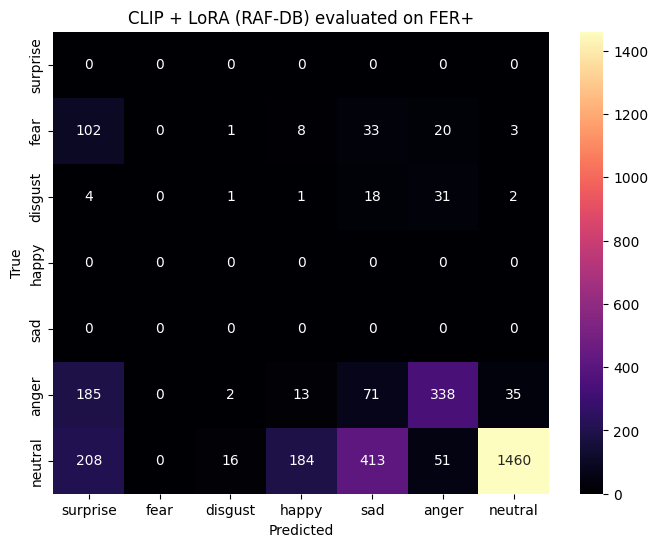

In [44]:
#Confusion Matrix

cm = confusion_matrix(labels_ferplus, preds_ferplus)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title("CLIP + LoRA (RAF-DB) evaluated on FER+")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

In [45]:
#Save model + head

torch.save(clip_lora.state_dict(), "clip_lora.pth")
torch.save(lora_head.state_dict(), "lora_head.pth")


In [46]:
#Final saves

import torch
import numpy as np
import os

os.makedirs("artifacts", exist_ok=True)

# Save LoRA model head
torch.save(lora_head.state_dict(), "artifacts/lora_head_rafdb.pt")

# torch.save(clip_lora.state_dict(), "artifacts/clip_lora_rafdb.pt")

# Save metrics
results = {
    "rafdb": {"acc": val_acc, "macro_f1": val_f1}, # Corrected variable names for RAF-DB
    "sfew":  {"acc": acc, "macro_f1": macro_f1},     # Corrected variable names for SFEW
    "ferplus": {"acc": acc_ferplus, "macro_f1": macro_f1_ferplus},
}
np.save("artifacts/results.npy", results, allow_pickle=True)


In [47]:
#Save the confusion-matrix plots as images

plt.savefig("artifacts/cm_ferplus.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [48]:
import torch
import os

# Define a directory in Google Drive for saving checkpoints and features
CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"
FEATURES_DIR = os.path.join(CHECKPOINTS_DIR, "features")
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(FEATURES_DIR, exist_ok=True)

# Save extracted features
# These variables (train_feats, train_labels, val_feats, val_labels) must be in scope from running cell A5IRCbVlG9Md
try:
    torch.save(train_feats, os.path.join(FEATURES_DIR, "train_feats.pt"))
    torch.save(train_labels, os.path.join(FEATURES_DIR, "train_labels.pt"))
    torch.save(val_feats, os.path.join(FEATURES_DIR, "val_feats.pt"))
    torch.save(val_labels, os.path.join(FEATURES_DIR, "val_labels.pt"))
    print(f"Extracted features and labels saved to {FEATURES_DIR}")
except NameError:
    print("Warning: `train_feats`, `train_labels`, `val_feats`, or `val_labels` not found. Please run feature extraction cell A5IRCbVlG9Md first.")

Extracted features and labels saved to /content/drive/MyDrive/EmotionEngine/checkpoints/features


In [49]:
import torch
import os
from torch.utils.data import TensorDataset, DataLoader

# Define the directory where features are saved
CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"
FEATURES_DIR = os.path.join(CHECKPOINTS_DIR, "features")

# Load extracted features
try:
    train_feats = torch.load(os.path.join(FEATURES_DIR, "train_feats.pt"))
    train_labels = torch.load(os.path.join(FEATURES_DIR, "train_labels.pt"))
    val_feats = torch.load(os.path.join(FEATURES_DIR, "val_feats.pt"))
    val_labels = torch.load(os.path.join(FEATURES_DIR, "val_labels.pt"))

    print("Successfully loaded extracted features and labels.")
    print("Train features:", train_feats.shape)
    print("Val features:  ", val_feats.shape)

    # Re-create DataLoaders for linear head training if needed
    train_ds_lin = TensorDataset(train_feats, train_labels)
    val_ds_lin   = TensorDataset(val_feats,   val_labels)

    train_loader_lin = DataLoader(train_ds_lin, batch_size=64, shuffle=True)
    val_loader_lin   = DataLoader(val_ds_lin,   batch_size=64, shuffle=False)
    print("Linear head DataLoaders re-created.")

except FileNotFoundError:
    print(f"Warning: Feature files not found in {FEATURES_DIR}. Please run the feature extraction cell `A5IRCbVlG9Md` first.")
except NameError:
    print("Warning: `CHECKPOINTS_DIR` or related paths not defined. Ensure necessary setup cells are run.")

Successfully loaded extracted features and labels.
Train features: torch.Size([12271, 512])
Val features:   torch.Size([3068, 512])
Linear head DataLoaders re-created.


In [50]:
import torch
import os

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"

# Save the trained LinearHead model
linear_head_save_path = os.path.join(CHECKPOINTS_DIR, "linear_head_rafdb.pt")
try:
    torch.save(linear_head.state_dict(), linear_head_save_path)
    print(f"Linear head model saved to: {linear_head_save_path}")
except NameError:
    print("Warning: `linear_head` not found. Please train the linear head in cell `Dv1wV3uCO6jB` first.")

Linear head model saved to: /content/drive/MyDrive/EmotionEngine/checkpoints/linear_head_rafdb.pt


In [51]:
import torch
import os

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"

# Define the path to the saved linear head model
linear_head_load_path = os.path.join(CHECKPOINTS_DIR, "linear_head_rafdb.pt")

# Initialize the LinearHead (assuming `feat_dim` and `num_classes` are defined)
try:
    # Assuming LinearHead class, feat_dim, and num_classes are defined in an earlier cell (zAbLBa4SO1gk)
    linear_head = LinearHead(feat_dim, num_classes).to(device)
    linear_head.load_state_dict(torch.load(linear_head_load_path, map_location=device))
    print(f"Linear head model loaded from: {linear_head_load_path}")
except FileNotFoundError:
    print(f"Warning: Linear head model not found at {linear_head_load_path}. Please train the linear head first.")
except NameError:
    print("Warning: `LinearHead` class, `feat_dim`, `num_classes`, or `device` not defined. Ensure necessary setup cells are run.")

Linear head model loaded from: /content/drive/MyDrive/EmotionEngine/checkpoints/linear_head_rafdb.pt


In [52]:
import os
import torch

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# Save both the LoRA-tuned CLIP model and the linear head
try:
    torch.save(clip_lora.state_dict(), os.path.join(CHECKPOINTS_DIR, "clip_rafdb_lora.pt"))
    torch.save(lora_head.state_dict(), os.path.join(CHECKPOINTS_DIR, "lora_head_rafdb.pt"))
    print(f"LoRA-tuned CLIP model and head saved to: {CHECKPOINTS_DIR}")
except NameError:
    print("Warning: `clip_lora` or `lora_head` not found. Please train them in cell `7FLlzdg1OWXJ` first.")

LoRA-tuned CLIP model and head saved to: /content/drive/MyDrive/EmotionEngine/checkpoints


In [53]:
import torch
import os
from peft import LoraConfig, get_peft_model, TaskType
from transformers import CLIPModel # Ensure CLIPModel is imported

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"

# Re-initialize CLIP model and LoRA config (assuming they are defined globally)
# This is crucial for `get_peft_model` to work correctly

try:
    # Load the base CLIP model again
    if 'clip_model' not in locals() or clip_model is None:
        clip_model_name = "openai/clip-vit-base-patch32"
        clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)

    if 'lora_config' not in locals() or lora_config is None:
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            lora_dropout=0.05,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],  # CLIP attention modules
        )

    clip_lora = get_peft_model(clip_model, lora_config)
    clip_lora.to(device)

    # Initialize the linear head (assuming `feat_dim` and `num_classes` are defined)
    if 'lora_head' not in locals() or lora_head is None:
        lora_head = LinearHead(feat_dim, num_classes).to(device)

    clip_lora.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, "clip_rafdb_lora.pt"), map_location=device))
    lora_head.load_state_dict(torch.load(os.path.join(CHECKPOINTS_DIR, "lora_head_rafdb.pt"), map_location=device))
    print(f"LoRA-tuned CLIP model and head loaded from: {CHECKPOINTS_DIR}")

    # Put models in evaluation mode after loading if you are not training further
    clip_lora.eval()
    lora_head.eval()

except FileNotFoundError:
    print(f"Warning: LoRA model or head not found at {CHECKPOINTS_DIR}. Please train them first.")
except NameError as e:
    print(f"Warning: Required variable not defined: {e}. Ensure necessary setup cells (Y__4tYTldtEN, X-c4Bdg_NmrM, VkqlcPk1NzAJ) are run.")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


LoRA-tuned CLIP model and head loaded from: /content/drive/MyDrive/EmotionEngine/checkpoints


In [54]:
import numpy as np
import os

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"
ZERO_SHOT_RESULTS_DIR = os.path.join(CHECKPOINTS_DIR, "zero_shot_results")
os.makedirs(ZERO_SHOT_RESULTS_DIR, exist_ok=True)

try:
    # These variables (all_labels, all_preds, zeroshot_acc, zeroshot_macro_f1) must be in scope from running cell iIyKmr0kih91
    np.save(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_all_labels.npy"), all_labels)
    np.save(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_all_preds.npy"), all_preds)

    # Save metrics in a dictionary for easy loading
    zeroshot_metrics = {
        "acc": zeroshot_acc,
        "macro_f1": zeroshot_macro_f1
    }
    np.save(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_metrics.npy"), zeroshot_metrics)

    print(f"Zero-shot results saved to {ZERO_SHOT_RESULTS_DIR}")
except NameError:
    print("Warning: `all_labels`, `all_preds`, `zeroshot_acc`, or `zeroshot_macro_f1` not found. Please run the zero-shot prediction cell `iIyKmr0kih91` first.")

In [55]:
import numpy as np
import os

CHECKPOINTS_DIR = "/content/drive/MyDrive/EmotionEngine/checkpoints"
ZERO_SHOT_RESULTS_DIR = os.path.join(CHECKPOINTS_DIR, "zero_shot_results")

try:
    all_labels = np.load(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_all_labels.npy"))
    all_preds = np.load(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_all_preds.npy"))
    zeroshot_metrics = np.load(os.path.join(ZERO_SHOT_RESULTS_DIR, "zeroshot_metrics.npy"), allow_pickle=True).item()

    zeroshot_acc = zeroshot_metrics["acc"]
    zeroshot_macro_f1 = zeroshot_metrics["macro_f1"]

    print("Successfully loaded zero-shot prediction results.")
    print("Zero-shot CLIP on VAL set (Loaded)")
    print("Accuracy:", zeroshot_acc)
    print("Macro-F1:", zeroshot_macro_f1)

except FileNotFoundError:
    print(f"Warning: Zero-shot result files not found in {ZERO_SHOT_RESULTS_DIR}. Please run the prediction cell `iIyKmr0kih91` first.")
except NameError:
    print("Warning: `CHECKPOINTS_DIR` or related paths not defined. Ensure necessary setup cells are run.")

In [56]:
#Final saves

import torch
import numpy as np
import os

artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Save metrics
# Ensure all required variables (zeroshot_acc, zeroshot_macro_f1, val_acc, macro_f1, val_f1, acc, macro_f1_ferplus) are in scope
try:
    results = {
        "zeroshot_rafdb": {"acc": zeroshot_acc, "macro_f1": zeroshot_macro_f1},
        "linear_probe_rafdb": {"acc": val_acc, "macro_f1": macro_f1}, # Assuming val_acc and macro_f1 are from linear probe
        "lora_rafdb":  {"acc": val_acc, "macro_f1": val_f1}, # Assuming val_acc and val_f1 here are from LoRA eval
        "sfew":  {"acc": acc, "macro_f1": macro_f1},     # Assuming acc and macro_f1 are from SFEW eval
        "ferplus": {"acc": acc_ferplus, "macro_f1": macro_f1_ferplus},
    }
    np.save(os.path.join(artifacts_dir, "results.npy"), results, allow_pickle=True)

    print(f"Final evaluation metrics saved to {os.path.join(artifacts_dir, 'results.npy')}")
except NameError as e:
    print(f"Warning: One or more required variables for saving results are not defined: {e}. Please ensure all evaluation steps have been run.")

Predicted Emotion: happy
Probabilities per emotion:
  surprise: 0.0264
  fear: 0.0288
  disgust: 0.0255
  happy: 0.7869
  sad: 0.0369
  anger: 0.0246
  neutral: 0.0709


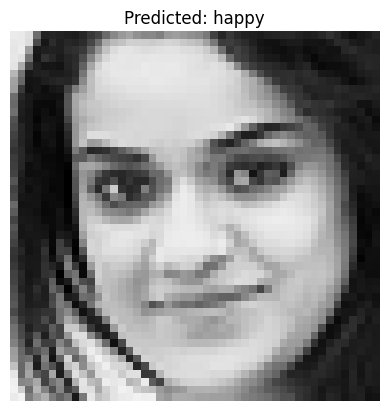

In [59]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0028643.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: sad
Probabilities per emotion:
  surprise: 0.0678
  fear: 0.1243
  disgust: 0.2066
  happy: 0.0275
  sad: 0.3236
  anger: 0.1958
  neutral: 0.0543


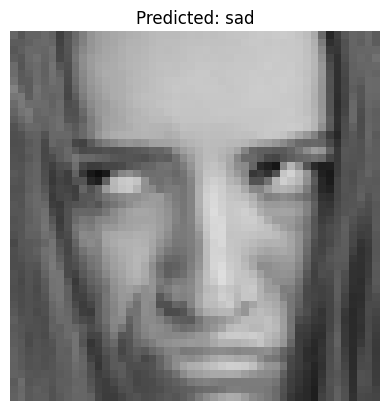

In [60]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0028963.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: anger
Probabilities per emotion:
  surprise: 0.1656
  fear: 0.1824
  disgust: 0.1779
  happy: 0.0473
  sad: 0.0524
  anger: 0.3417
  neutral: 0.0327


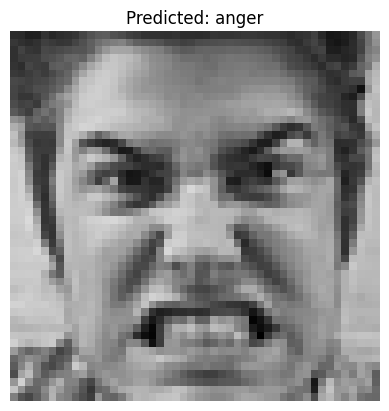

In [61]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0028678.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: surprise
Probabilities per emotion:
  surprise: 0.3117
  fear: 0.1567
  disgust: 0.1601
  happy: 0.0297
  sad: 0.0506
  anger: 0.2567
  neutral: 0.0346


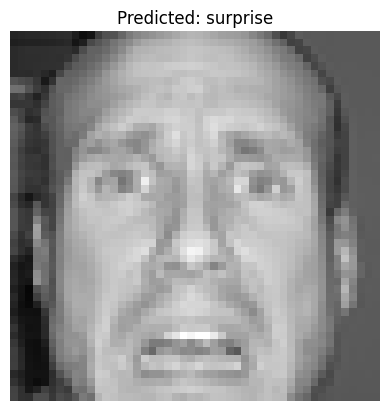

In [62]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0029042.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: surprise
Probabilities per emotion:
  surprise: 0.5019
  fear: 0.1116
  disgust: 0.0938
  happy: 0.0660
  sad: 0.0344
  anger: 0.1396
  neutral: 0.0526


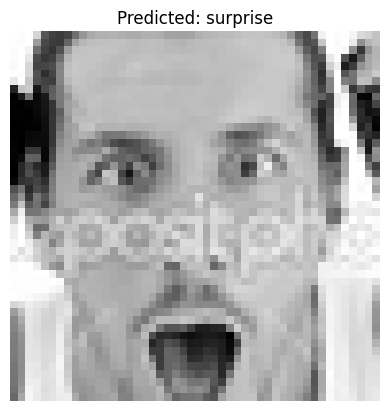

In [63]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0028702.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: anger
Probabilities per emotion:
  surprise: 0.1382
  fear: 0.1740
  disgust: 0.2057
  happy: 0.0387
  sad: 0.0777
  anger: 0.3303
  neutral: 0.0353


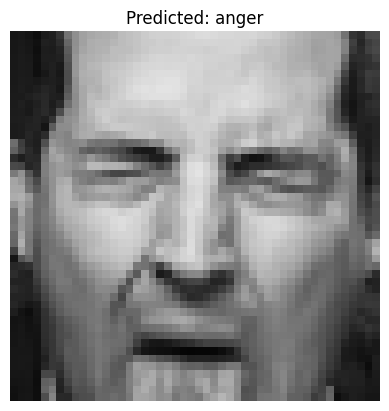

In [64]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/fer0032254.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: sad
Probabilities per emotion:
  surprise: 0.0522
  fear: 0.0759
  disgust: 0.1390
  happy: 0.0306
  sad: 0.5129
  anger: 0.0902
  neutral: 0.0992


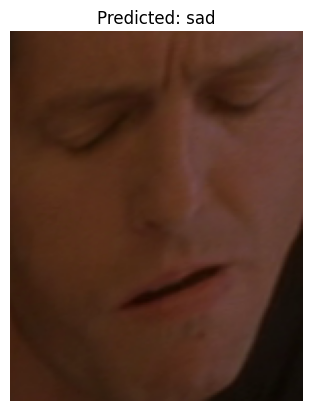

In [65]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/AboutABoy_010940087_00000024.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: neutral
Probabilities per emotion:
  surprise: 0.0496
  fear: 0.0365
  disgust: 0.0527
  happy: 0.0973
  sad: 0.0698
  anger: 0.0329
  neutral: 0.6613


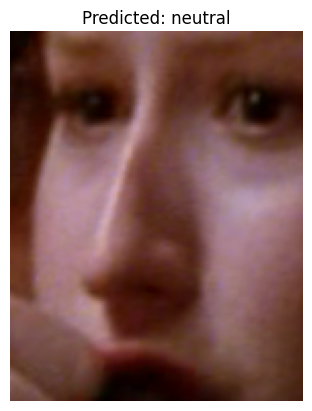

In [66]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/PrettyInPink_011006040_00000010.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: surprise
Probabilities per emotion:
  surprise: 0.4283
  fear: 0.1237
  disgust: 0.1091
  happy: 0.0873
  sad: 0.0475
  anger: 0.1525
  neutral: 0.0515


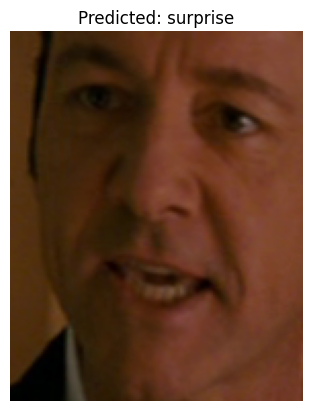

In [67]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "//21_012246400_00000059.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: surprise
Probabilities per emotion:
  surprise: 0.5094
  fear: 0.1018
  disgust: 0.0899
  happy: 0.0694
  sad: 0.0533
  anger: 0.1112
  neutral: 0.0651


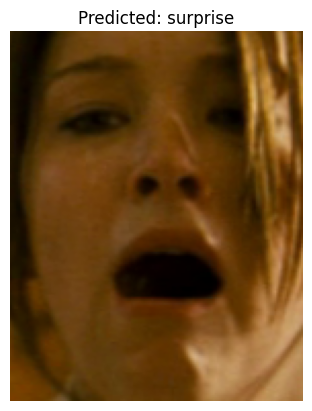

In [68]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/HauntingMollyHartely_010024680_00000029.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: happy
Probabilities per emotion:
  surprise: 0.0552
  fear: 0.0380
  disgust: 0.0301
  happy: 0.7688
  sad: 0.0301
  anger: 0.0348
  neutral: 0.0429


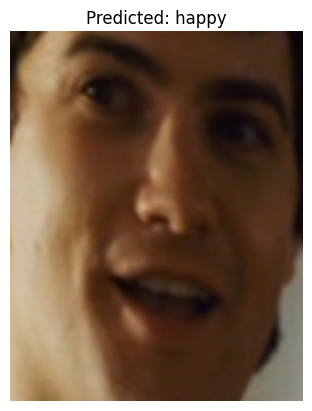

In [70]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/21_001703120_00000003.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()

Predicted Emotion: neutral
Probabilities per emotion:
  surprise: 0.0690
  fear: 0.0389
  disgust: 0.0565
  happy: 0.1068
  sad: 0.0861
  anger: 0.0344
  neutral: 0.6083


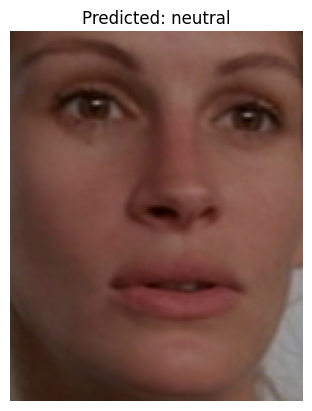

In [72]:
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def predict_emotion(image_path, model, head, processor, device, label_names=EMOTIONS):
    model.eval()
    head.eval()

    # Load image from URL or path
    if image_path.startswith("http"): # Check if it's a URL
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        logits = head(feats)
        probs = F.softmax(logits, dim=-1).cpu().numpy().flatten()

    top_idx = probs.argmax()
    return label_names[top_idx], probs


# Example Usage
# clip_lora, lora_head, clip_processor, device, and EMOTIONS are defined from previous cells
# Example image path
# Using a sample image from the FER+ dataset that might be in /content or linked

sample_image_path = "/NottingHill_010958154_00000058.png" # This path is from the kernel state

# Ensure the model and head are in evaluation mode and on the correct device
clip_lora.eval()
lora_head.eval()

predicted_emotion, probabilities = predict_emotion(
    sample_image_path,
    clip_lora,
    lora_head,
    clip_processor,
    device,
    label_names=EMOTIONS
)

print(f"Predicted Emotion: {predicted_emotion}")
print("Probabilities per emotion:")
for i, prob in enumerate(probabilities):
    print(f"  {EMOTIONS[i]}: {prob:.4f}")

# Display the image


plt.imshow(Image.open(sample_image_path).convert("RGB"))
plt.title(f"Predicted: {predicted_emotion}")
plt.axis('off')
plt.show()